# Example of quantification of SYTOX fluor profile vs phase (cells) in wide-trenches microfluidics

__Steps__:
1. Download zip folder for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench.zip'
2. First, we run 'compute_kymo_fluor_wide-trench.py' to apply background subtraction, detect wide-trenches boundaries automatically, and extract fluorescence and phase contrast signal information over time, and projected (averaged) onto the y-axis (along the trench)
3. Then, we plot the single-trench and ensemble kymographs
4. Analysis of the LL-37 fluor signal (Figure 5H, S8E-G) is analogous

__Requirements on how to run__:
1. This notebook assumes the OmniSegger-processed extracted file data folder, here 'CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench', lives in the same folder as the notebook
2. The function libraries 'analysis_functions_library.py' and 'quantify_fluor_kymo_functions.py' are pulled from the repository folder '2_singlecell_microwells' and '3_widetrench_microfluidics/fluorescence_kymographs', respectively

__Code underlying data and figures__:
- Wide-trenches data, quantification of SYTOX fluor or LL-37 fluor in wide-trenches, with strains CJW7845 or CJW7859, respectively
- Figures 5G-H and SC-G

### 1. Run 'compute_kymo_fluor_wide-trench.py'

Run time: < 1hr per position

In [1]:
'''Compute and export fluorescence kymographs for wide-trench microscopy data.

Steps:
1) Detect wide-trench positions from the phase contrast signal using Omnipose masks:
   - Background-subtract phase and fluor channels
   - Use the closed/filled Omnipose mask to restrict phase to the cell-occupied region
   - Call get_trench_xycoords() to locate individual trench x-coordinates from the
     averaged phase intensity profile; extrapolate missing trenches from the periodic pitch
2) Extract kymographs for each channel (fluor/SYTOX and phase):
   - Per-frame: extract expanded crops around each trench, average into ensemble 2D frame
     and 1D y-profile (kymograph row)
   - Per-trench: link crops across frames by x_center to build single-trench kymographs
3) Save all outputs (arrays, dataframes, metadata) to output_folder_kymo/
4) Load saved outputs, pool across positions, and plot:
   - Ensemble overlay kymograph: phase (greyscale) + fluor (green), time-aligned to AMP injection
   - Single-trench side-by-side: raw crop image overlaid with fluorescence + individual kymograph
'''

import sys, os, re, gc, glob, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import torch
import cupy as cp
from scipy.signal import find_peaks, savgol_filter
from scipy import ndimage
from scipy import ndimage as ndi_np
from skimage.morphology import disk
import imageio.v3 as iio
warnings.filterwarnings('ignore')

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count())
cp.cuda.Device(0).use()

# --- import libraries (replaces the two runfile() calls) ---
sys.path.append(str(Path("../../2_singlecell_microwells").resolve()))
sys.path.append(str(Path("../../3_widetrench_microfluidics/fluorescence_kymographs").resolve()))
from analysis_functions_library import *          # create_pos_list, local_bkg_sub_cp, get_fluor_mask, ...
from quantify_fluor_kymo_functions import *        # get_trench_xycoords, extract_expanded_trench_ensemble, ...

'''Global variables'''
fr = 1
px_size = 0.065841
offs_x = 10
offs_y = 10
save = True
bkg_sub = True
show = False
overwrite = True
disk50 = disk(50)

'''Single experiment (local)'''
experiment_path = "CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench"   # extracted archive folder, next to the notebook
exp_name = experiment_path
AMP_name = "LL-37_2uM"
rep_name = "rep1"

# read fr_inj from the notes file
notes_file = next(Path(experiment_path).glob("notes_*.txt"), None)
if notes_file:
    print(notes_file.read_text())

Device: cuda | CUDA: True | GPUs: 2
260113, CJW7753

37degC, M9GluCAAT (0.2% Glu, 0.4% CAA)

FR = 1 min interval 

SYTOX Green 5nM

xy01-03: LL-37, 2uM --> switch to AMP: 23/24






In [2]:
fr_inj = 23         # <-- set from the notes above (frame right before AMP injection)

In [3]:

pos_list = sorted([d for d in os.listdir(experiment_path) if d.startswith('xy')])
ch_list = ['phase', 'fluor1']                      # phase + SYTOX;
ch_fluor_list = [s for s in ch_list if 'fluor1' in s]   # SYTOX (permeabilization) channel only

In [4]:
pos_list = ['xy01']   # eliminate to run on all positions

### Run wide-trenches identification, tracking, and fluorescence profile extraction for SYTOX Green, and cropped phase contrast using Omnipose masks from phase

xy01
0
3


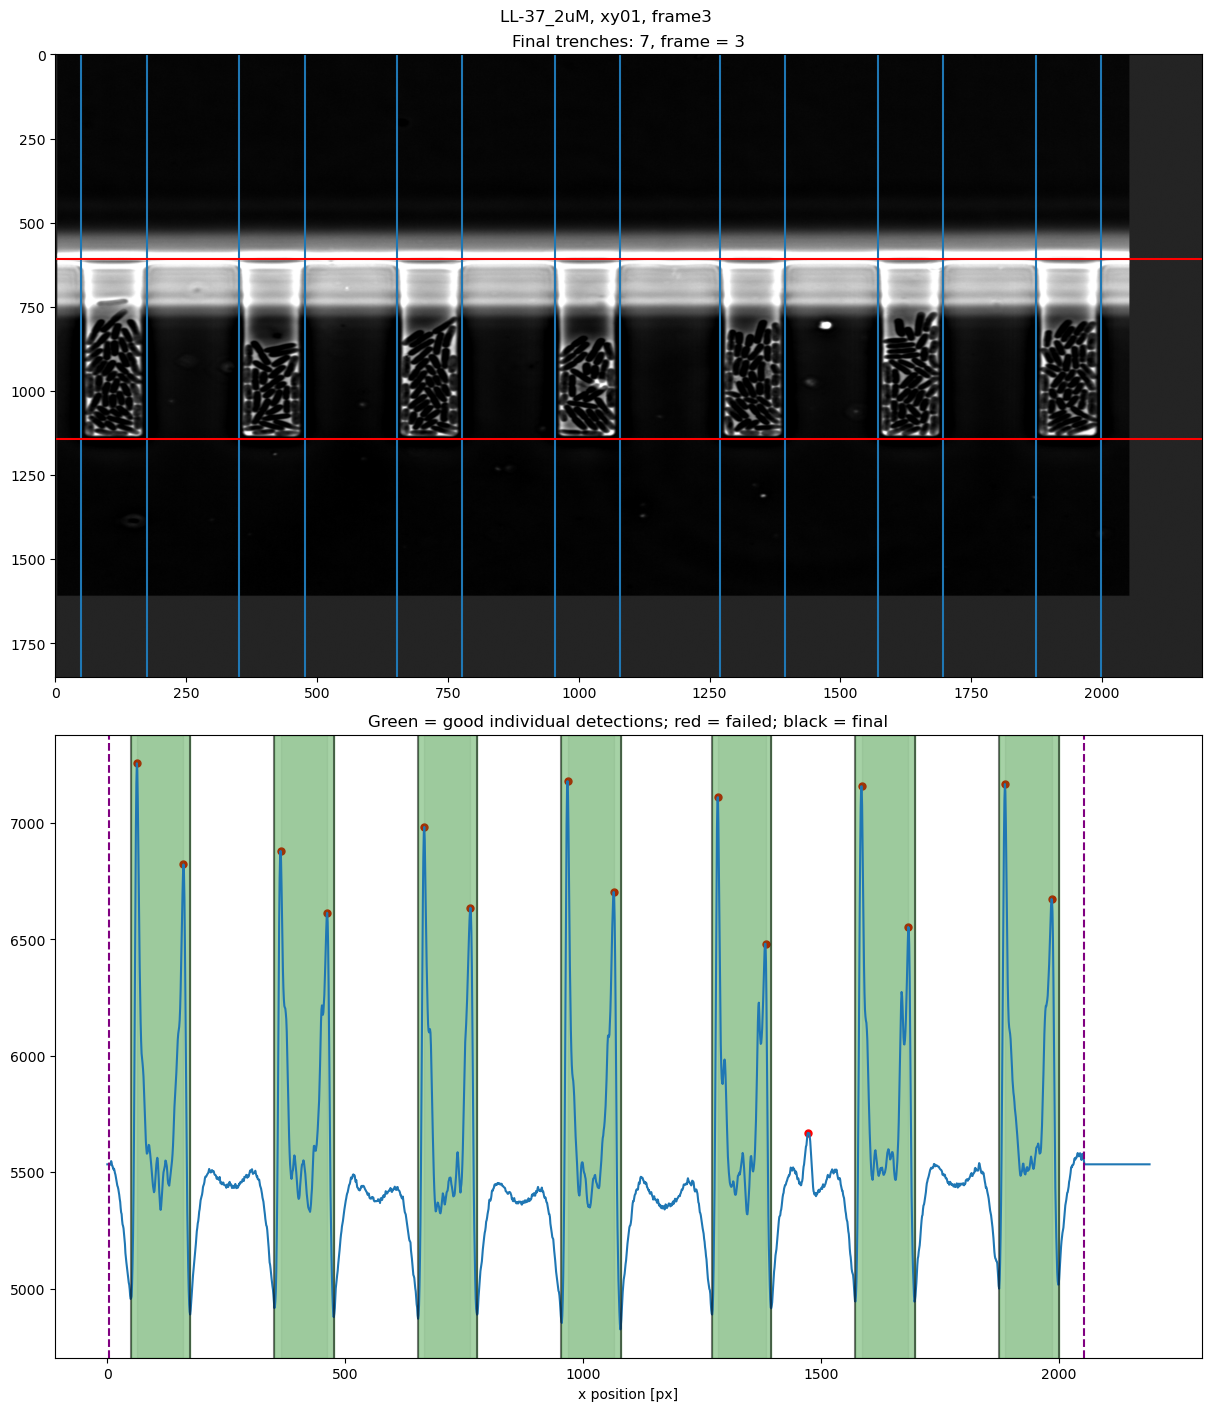

Peak distances: [ 98 204  98 204  97 204  97 219 100  89 113  98 203  98]
Good xcoords: [(49, 174), (351, 476), (652, 777), (954, 1079), (1270, 1395), (1572, 1697), (1874, 1999)]
Final xcoords: [(49, 174), (351, 476), (652, 777), (954, 1079), (1270, 1395), (1572, 1697), (1874, 1999)]
y0, y1: 608 1143
Trench height: 535 px
Saved sytox kymo outputs for xy01: xy01_CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench_sytox_kymo
Saved phase kymo outputs for xy01: xy01_CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench_phase_kymo
Saved trench metadata for xy01
No sytox single-trench tracks to save for xy01
No phase single-trench tracks to save for xy01


In [5]:
show_trench = True
for pos in pos_list:
    folder_path = experiment_path + '/' + pos
    cells_path = folder_path + "/cell"
    mask_path = folder_path + '/masks'

    pos_num = re.findall(r'\d+', pos)[0]
    if not os.path.exists(cells_path):
        continue
    elif len(os.listdir(cells_path)) == 0:
        continue
    print(pos)
    if os.path.exists(mask_path):
        masks_list = os.listdir(mask_path)

    paths_dict = {}
    file_list_dict = {}
    for ch in ch_list:
        paths_dict[ch] = folder_path + '/' + ch
        file_list_dict[ch] = os.listdir(paths_dict[ch])
    phase_list = file_list_dict['phase']
    phase_path = paths_dict['phase']

    if not overwrite:
        output_path = os.path.join(experiment_path, 'output_folder_kymo')
        if os.path.exists(output_path):
            check_name = pos + '_' + exp_name + '_sytox_kymo_arrays.npz'
            if check_name in os.listdir(output_path):
                print(check_name + ' was already computed -->> skip')
                continue

    for ch in ch_fluor_list:
        fluor_list = file_list_dict[ch]
        fluor_path = paths_dict[ch]

        pad = 300
        bin_size = 5
        sytox_profiles, sytox_avg_2d_frames = [], []
        phase_profiles, phase_avg_2d_frames = [], []
        frame_ids = []
        trench_rel_box = None
        trench_box_rows = []
        frame_summary_rows = []
        single_trench_records_sytox = []
        single_trench_records_phase = []
        if "LL-37" in AMP_name:
                peak_p, search_aft, fixed_gap = 650, 1000, 179
        elif "CecA" in AMP_name:
                peak_p, search_aft, fixed_gap = 800, 1150, 180
        else:
                raise ValueError(f"No trench params defined for AMP_name={AMP_name!r}")
        for k in range(len(fluor_list))[:5]:        # REMOVE [:5] if running on whole time-lapse
            mask_temp = iio.imread(mask_path + '/' + masks_list[k])
            phase_temp = iio.imread(phase_path + '/' + phase_list[k])
            fluor_temp = iio.imread(fluor_path + '/' + fluor_list[k])

            bs = int(fluor_temp.shape[0] / 16)
            fluor_bkg_sub, _, _ = local_bkg_sub_cp(
                fluor_temp, mask_temp, pos, exp_name, frame=str(k),
                box_size=bs, dilations=15, sigma_=60, show=False)

            bs = int(fluor_temp.shape[0] / 64)
            phase_temp_bkg_sub, mask_temp, _ = local_bkg_sub_cp(
                phase_temp, mask_temp, pos, exp_name, frame=str(k),
                box_size=bs, dilations=1, sigma_=25, show=False)

            mask_dil = ndi_np.binary_closing(mask_temp > 0, structure=disk50, brute_force=True)
            mask_dil = ndi_np.binary_fill_holes(mask_dil)
            phase_temp_bkg_sub *= mask_dil

            if k%50 ==0:
                print(k)

            if show_trench and k == 3:
                print(k)
                show_tr = True
            else: show_tr = False


            title_plot = AMP_name + ', ' + pos + ', frame' + str(k)
            trench_boxes, phase_avg_x, peaks, ensemble_y_profile = get_trench_xycoords(
                phase_temp, peak_distance=60, peak_prominence=peak_p,
                trench_width_range=(70, 130), gap_width_range=(150, 250),
                edge_search_px=100, min_edge_drop=100, fixed_trench_width_px=125,
                fixed_gap_px=fixed_gap, refined_width_tolerance_px=45,
                extrapolate_missing=True, trench_height_px=535,
                search_after=search_aft, show=show_tr, frame=k, title=title_plot)

            sytox_result = extract_expanded_trench_ensemble(
                fluor_bkg_sub, trench_boxes, pad=pad, kymo_use_trench_x_only=True, kymo_x_inset_px=50)
            phase_result = extract_expanded_trench_ensemble(
                phase_temp_bkg_sub, trench_boxes, pad=pad, kymo_use_trench_x_only=True, kymo_x_inset_px=50)
            if sytox_result is None or phase_result is None:
                continue

            sytox_y_profile, sytox_frame_avg_2d, sytox_expanded_crops, used_trench_boxes, trench_rel_box = sytox_result
            phase_y_profile, phase_frame_avg_2d, phase_expanded_crops, _, _ = phase_result

            for crop_i, (tr_id, y0, y1, x0, x1) in enumerate(used_trench_boxes):
                rec_base = {'frame': k, 'trench_id_raw': tr_id, 'x0': x0, 'x1': x1,
                            'y0': y0, 'y1': y1, 'x_center': 0.5 * (x0 + x1)}
                rec_sytox = rec_base.copy(); rec_sytox['crop'] = sytox_expanded_crops[crop_i]
                rec_phase = rec_base.copy(); rec_phase['crop'] = phase_expanded_crops[crop_i]
                single_trench_records_sytox.append(rec_sytox)
                single_trench_records_phase.append(rec_phase)
                trench_box_rows.append({
                    'exp_name': exp_name, 'AMP': AMP_name, 'rep': rep_name, 'pos': pos, 'frame': k,
                    'trench_id': tr_id, 'y0': y0, 'y1': y1, 'x0': x0, 'x1': x1, 'pad': pad,
                    'rel_y0': trench_rel_box['y0'], 'rel_y1': trench_rel_box['y1'],
                    'rel_x0': trench_rel_box['x0'], 'rel_x1': trench_rel_box['x1']})

            sytox_profiles.append(sytox_y_profile); sytox_avg_2d_frames.append(sytox_frame_avg_2d)
            phase_profiles.append(phase_y_profile); phase_avg_2d_frames.append(phase_frame_avg_2d)
            frame_ids.append(k)
            frame_summary_rows.append({
                'exp_name': exp_name, 'AMP': AMP_name, 'rep': rep_name, 'pos': pos, 'frame': k,
                'n_trenches_used': len(sytox_expanded_crops),
                'mean_sytox': float(np.nanmean(sytox_frame_avg_2d)), 'max_sytox': float(np.nanmax(sytox_frame_avg_2d)),
                'median_sytox': float(np.nanmedian(sytox_frame_avg_2d)),
                'mean_phase': float(np.nanmean(phase_frame_avg_2d)), 'max_phase': float(np.nanmax(phase_frame_avg_2d)),
                'median_phase': float(np.nanmedian(phase_frame_avg_2d))})

        single_trench_records_sytox = link_trench_records(single_trench_records_sytox, max_dx=40)
        single_trench_records_phase = link_trench_records(single_trench_records_phase, max_dx=40)
        track_outputs_sytox = build_single_trench_kymos(
            single_trench_records_sytox, trench_rel_box=trench_rel_box,
            min_frames=20, kymo_use_trench_x_only=True, kymo_x_inset_px=50)
        track_outputs_phase = build_single_trench_kymos(
            single_trench_records_phase, trench_rel_box=trench_rel_box,
            min_frames=20, kymo_use_trench_x_only=True, kymo_x_inset_px=50)

        if save and ch == 'fluor1' and len(sytox_profiles) > 0:
            output_folder_kymo = os.path.join(experiment_path, 'output_folder_kymo')
            save_channel_kymo_outputs(output_folder_kymo=output_folder_kymo, pos=pos, exp_name=exp_name,
                AMP_name=AMP_name, rep_name=rep_name, channel_name='sytox', frame_ids=frame_ids,
                profiles=sytox_profiles, avg_2d_frames=sytox_avg_2d_frames, trench_rel_box=trench_rel_box, bin_size=bin_size)
            save_channel_kymo_outputs(output_folder_kymo=output_folder_kymo, pos=pos, exp_name=exp_name,
                AMP_name=AMP_name, rep_name=rep_name, channel_name='phase', frame_ids=frame_ids,
                profiles=phase_profiles, avg_2d_frames=phase_avg_2d_frames, trench_rel_box=trench_rel_box, bin_size=bin_size)
            save_trench_metadata_outputs(output_folder_kymo=output_folder_kymo, pos=pos, exp_name=exp_name,
                trench_box_rows=trench_box_rows, frame_summary_rows=frame_summary_rows)
            save_single_trench_track_outputs(output_folder_kymo=output_folder_kymo, pos=pos, exp_name=exp_name,
                AMP_name=AMP_name, rep_name=rep_name, channel_name='sytox',
                track_outputs=track_outputs_sytox, trench_rel_box=trench_rel_box)
            save_single_trench_track_outputs(output_folder_kymo=output_folder_kymo, pos=pos, exp_name=exp_name,
                AMP_name=AMP_name, rep_name=rep_name, channel_name='phase',
                track_outputs=track_outputs_phase, trench_rel_box=trench_rel_box)

## Plot single-trench and ensemble kymographs

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path("../../3_widetrench_microfluidics/fluorescence_kymographs").resolve()))
from quantify_fluor_kymo_functions import *          # replaces the runfile()

'''Settings'''
experiment_path    = "CJW7845_LL-37_2uM_5nM_SYTOX_wide-trench"    # extracted archive folder, next to the notebook
output_folder_kymo = os.path.join(experiment_path, 'output_folder_kymo')     # where the compute step saved outputs
output_folder_fig  = os.path.join(experiment_path, 'output_kymo_figures')

master_folder_path = experiment_path      # see note below (only used by the crop-extraction section)

AMP_title    = "LL-37 2µM"
AMP_name     = "LL-37_2uM"
signal_name  = "SYTOX"
channel_name  = "sytox"
fluor_channel = "fluor1"
fr_inj = 23          # frame index at which AMP was added

os.makedirs(output_folder_fig, exist_ok=True)

__Single-trench__

In [19]:
'''=== One example single-trench crop + kymograph overlay ==='''
single_tracks_signal = load_single_trench_tracks(output_folder_kymo, channel_name=channel_name)
single_tracks_phase  = load_single_trench_tracks(output_folder_kymo, channel_name="phase")

Loaded 7 sytox tracked single trenches
Loaded 7 phase tracked single trenches


In [20]:
track_indices = find_track_indices_by_pos(single_tracks_signal, "xy01")
track_index = track_indices[1]        # or whichever index you want

Track indices at xy01: [0, 1, 2, 3, 4, 5, 6]
Applied kymo y-shift: 0 px


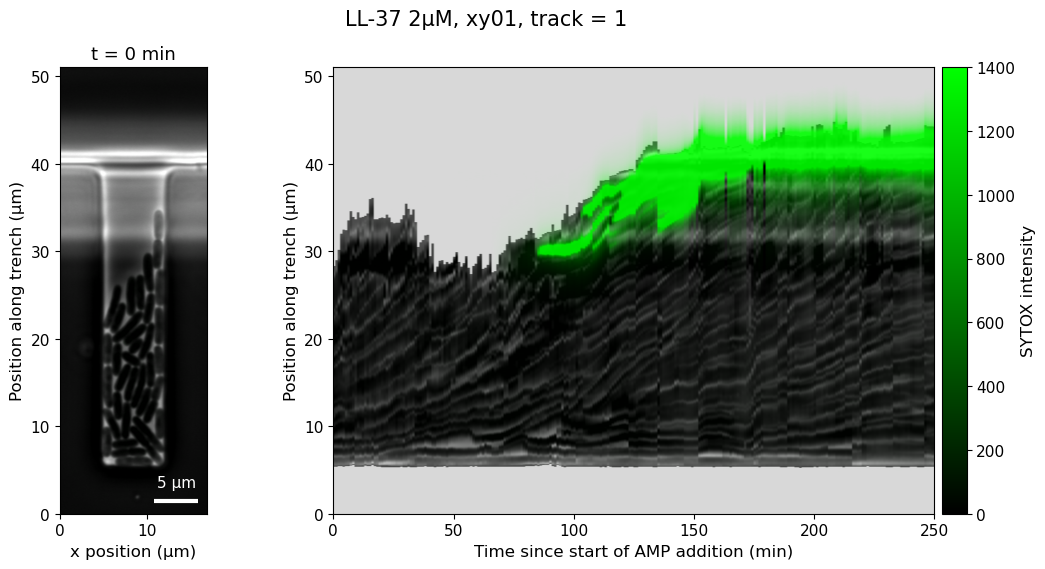

In [21]:
'''=== Plot one specific single-trench crop + full kymograph ==='''
phase_lookup = make_phase_track_lookup(single_tracks_phase)

# --- choose the trench ---
pos_to_plot = "xy01"        # position
which = track_index                   # use different indexes to plot kymographs of different single trenches

track_indices = find_track_indices_by_pos(single_tracks_signal, pos_to_plot)
print(f"Track indices at {pos_to_plot}: {track_indices}")
track_index = track_indices[which]

tr_s = single_tracks_signal[track_index]
key = get_track_match_key(tr_s)
if key not in phase_lookup:
    raise ValueError(f"No matching phase track for {key}")
phase_idx = phase_lookup[key]

crop_records = extract_tracked_trench_crops_for_frames(
    single_tracks_sytox=single_tracks_signal,
    track_index=track_index,
    frames_to_extract=[fr_inj, fr_inj + 30, fr_inj + 60, fr_inj + 100],
    output_folder_kymo=output_folder_kymo,
    master_folder_path=master_folder_path,
    fluor_channel=fluor_channel,
    signal_bkg_sub=True,
    pad_x=65, pad_top=300, pad_bottom=100,
    max_frame_delta=2, use_sorted=False,
)

track_id = int(tr_s["track_id"])
pos = tr_s["metadata"].get("pos")
crop_i = 0
frame_used = int(crop_records[crop_i]["frame"])
pdf_path_single = os.path.join(
    output_folder_fig,
    f"{AMP_name}_{pos}_track_{track_id:03d}_frame_{frame_used:04d}_crop_kymo_overlay.pdf")

plot_selected_crop_and_track_kymo(
    crop_records=crop_records,
    single_tracks_sytox=[tr_s],
    single_tracks_phase=[single_tracks_phase[phase_idx]],
    crop_record_index=crop_i,
    track_index=0,
    fr_inj=fr_inj,
    AMP_title=AMP_title + f', {pos}, track = {track_index}',
    signal_name=signal_name,
    manual_signal_vmin=0,
    manual_signal_vmax=1400,
    crop_phase_vmin_prc=5,
    crop_phase_vmax_prc=99.5,
    kymo_phase_vmin_prc=5,
    kymo_phase_vmax_prc=99.5,
    phase_invert=False,
    signal_alpha=0.9,
    zero_background="light_grey",
    overlay_mode="green",
    kymo_tlims_min=(0, 250),
    ylims_px=(25, 800),
    ytick_step_um=10,
    scale_bar_um=5,
    save_path=pdf_path_single,
    show=True,
)

__Multi-trench (ensemble)__

Loaded 3 sytox datasets
Loaded 3 phase datasets


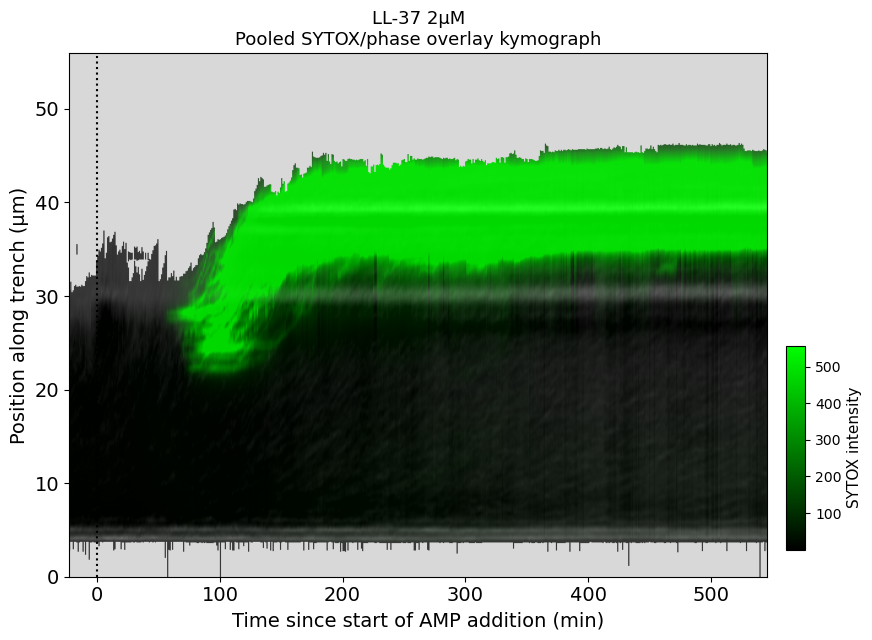

In [23]:
'''=== Ensemble overlay kymograph (pooled across positions) ==='''
signal_datasets = load_channel_kymo_npz_files(output_folder_kymo, channel_name=channel_name)
phase_datasets  = load_channel_kymo_npz_files(output_folder_kymo, channel_name="phase")

signal_frame_ids, signal_kymo, signal_2d_frames, signal_n_pos = pool_channel_datasets_by_frame(signal_datasets)
phase_frame_ids,  phase_kymo,  phase_2d_frames,  phase_n_pos  = pool_channel_datasets_by_frame(phase_datasets)

trench_rel_box = signal_datasets[0]["metadata"]["trench_rel_box"]

pdf_path = os.path.join(output_folder_fig, f"{AMP_name}_{signal_name}_phase_overlay_pooled_kymograph.pdf")
plot_pooled_overlay_kymograph(
    pooled_frame_ids=signal_frame_ids,
    pooled_kymo_signal=signal_kymo,
    pooled_kymo_phase=phase_kymo,
    fr_inj=fr_inj,
    trench_rel_box=trench_rel_box,
    AMP_title=AMP_title,
    signal_name=signal_name,
    overlay_mode="green",
    signal_vmin_prc=40,
    signal_vmax_prc=90,
    phase_vmin_prc=15,
    phase_vmax_prc=100,
    phase_invert=False,
    signal_alpha=0.85,
    zero_background="light_grey",
    show_trench_lines=False,
    ylims_px=(250, 1100),
    ytick_step_um=10,
    save_path=pdf_path,
)
